## Supernova distrances

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\domen\AppData\Local\Temp\ipykernel_7544\3381188307.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

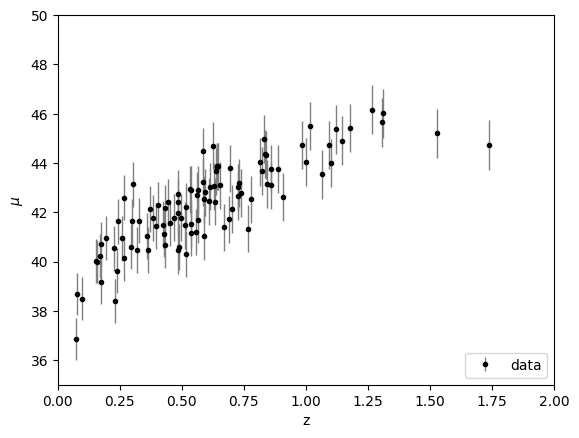

In [4]:
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

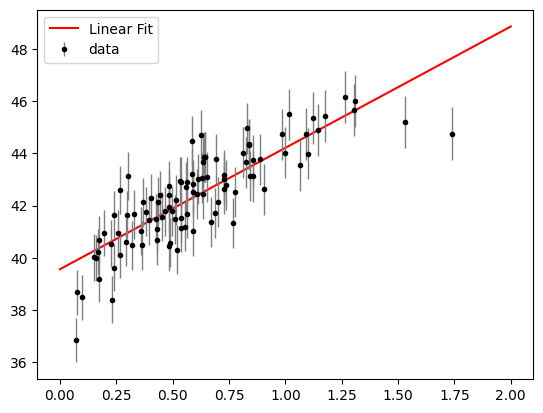

In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Fit a linear regression model to the data
model = LinearRegression()
model.fit(z_sample.reshape(-1, 1), mu_sample)
# Predict the values of mu for the given z values
z_pred = np.linspace(0, 2, 100)
mu_pred = model.predict(z_pred.reshape(-1, 1))
# Plot the predicted values
plt.plot(z_pred, mu_pred, color='red', label='Linear Fit')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

dmu = generate_mu_z(100, random_state=1234)  # errore costante su tutti i punti

# Fit a linear regression model with weights (inverse of variance)
weights = 1 / dmu**2  # assuming dmu is the standard deviation
model = LinearRegression()
model.fit(z_sample.reshape(-1, 1), mu_sample, sample_weight=weights)

# Predict
z_pred = np.linspace(0, 2, 100)
mu_pred = model.predict(z_pred.reshape(-1, 1))

# Plot
plt.plot(z_pred, mu_pred, color='red', label='Weighted Linear Fit')
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.legend()
plt.show()


TypeError: unsupported operand type(s) for ** or pow(): 'tuple' and 'int'

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\domen\AppData\Local\Temp\ipykernel_7252\2584916294.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


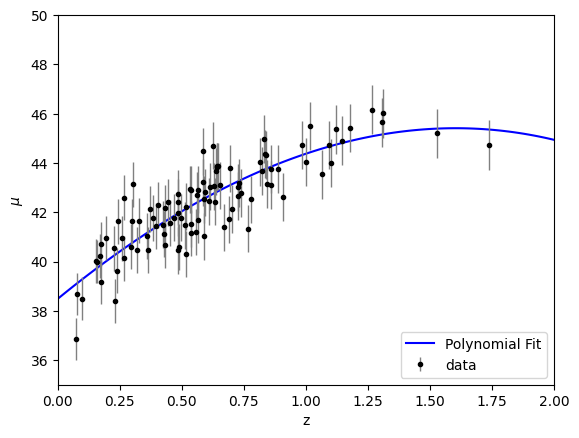

In [18]:
from sklearn.preprocessing import PolynomialFeatures
# Create polynomial features
poly = PolynomialFeatures(degree=3)   #penso che il polinomio di terzo grado sia il migliore
# Transform the data
z_poly = poly.fit_transform(z_sample.reshape(-1, 1))
# Fit a linear regression model to the polynomial features
model = LinearRegression()
model.fit(z_poly, mu_sample)
# Predict the values of mu for the given z values
z_poly_pred = poly.transform(z_pred.reshape(-1, 1))
mu_poly_pred = model.predict(z_poly_pred)
# Plot the predicted values
plt.plot(z_pred, mu_poly_pred, color='blue', label='Polynomial Fit')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

In [ ]:
#Define our functional form
def func(x, dy=0.1):
    return np.random.normal(np.sin(x) * x, dy)

#------------------------------------------------------------
# select the (noisy) data
np.random.seed(0)
x = np.linspace(0, 3, 22)[1:-1]
dy = 0.1
y = func(x, dy)

#------------------------------------------------------------
# Select the cross-validation points
np.random.seed(1)
x_cv = 3 * np.random.random(20)
y_cv = func(x_cv)

x_fit = np.linspace(0, 3, 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(x, y, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, x) - y) ** 2)
                              / len(y))
    crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2)
                              / len(y_cv))

BIC_train = np.sqrt(len(y)) * training_err / dy + d * np.log(len(y))
BIC_crossval = np.sqrt(len(y)) * crossval_err / dy + d * np.log(len(y))

ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')

ax.set_xlim(0, 14)
ax.set_ylim(0, 0.8)

ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)
